### Dependencies

In [ ]:
%pip install imreg_dft
%pip install numpy
%pip install matplotlib
%pip install opencv-python
%pip install pyqtgraph
%pip install PyQt6
%pip install scipy


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Guide to processing drone videos

This quick guide will walk you through processing our drone videos into usable data.

Insert which flight you're currently processing: **SUAS CLASS ONLY**

## Video directory

This directory should have the video frames (RJPEG files, .jpg) in it. Please avoid changing the filenames of, deleting, or otherwise altering frames in a video without re-running everything in this notebook. I.e., if you change something early in the pipeline, start from the beginning.

## Save directory

This directory is where any generated files will get dumped.

Directory is created if it doesn't already exist.

## Preprocess Video

### Extract frame-by-frame metadata

This script will go through each frame and extract relevant positional metadata, saving it in a numpy file. If you restart the jupyter kernel after running this, you don't have to run it again because the file will be saved.

### Load Metadata

Here we load the positional metadata, and we want to find a range of frames to extract data from, and that registration should work well on. Here I select frames where the drone is moving up or down and is not rotated far from the center. For flight #7, it looks like the drone is on the move from frame 0 to frame 80, so I will restrict the processing to those frames. Your research will likely not restrict utilizing these other frames.

Pull metadata

In [12]:
import numpy as np
import os, sys
import matplotlib.pyplot as plt
import csv

# Add current working directory (cwd) to PATH
sys.path.append(os.path.abspath(os.getcwd()))
flight = "flight5" 
descent_portion_cutoff_frame = 57

# Point to a specific flight
datadir = f"/local/data/imgs589/2251-2255/flights/20251027/high_gain/{flight}"

savedir = f"./high_gain_{flight}_save/"
os.makedirs(savedir, exist_ok=True)

from metadata_to_np import metadata_to_np
metadata_to_np(datadir, os.path.join(savedir, "flight_metadata.npy"))

metadata = np.load(os.path.join(savedir, "flight_metadata.npy"))
altitude_abs = metadata[:,0] # Above Sea Level (ASL)
altitude_rel = metadata[:,1] # Above Ground Level (AGL)
gimbal_roll = metadata[:,2]
gimbal_yaw = metadata[:,3]
gimbal_pitch = metadata[:,4]
flight_roll = metadata[:,5]
flight_yaw = metadata[:,6]
flight_pitch = metadata[:,7]

1/126
2/126
3/126
4/126
5/126
6/126
7/126
8/126
9/126
10/126
11/126
12/126
13/126
14/126
15/126
16/126
17/126
18/126
19/126
20/126
21/126
22/126
23/126
24/126
25/126
26/126
27/126
28/126
29/126
30/126
31/126
32/126
33/126
34/126
35/126
36/126
37/126
38/126
39/126
40/126
41/126
42/126
43/126
44/126
45/126
46/126
47/126
48/126
49/126
50/126
51/126
52/126
53/126
54/126
55/126
56/126
57/126
58/126
59/126
60/126
61/126
62/126
63/126
64/126
65/126
66/126
67/126
68/126
69/126
70/126
71/126
72/126
73/126
74/126
75/126
76/126
77/126
78/126
79/126
80/126
81/126
82/126
83/126
84/126
85/126
86/126
87/126
88/126
89/126
90/126
91/126
92/126
93/126
94/126
95/126
96/126
97/126
98/126
99/126
100/126
101/126
102/126
103/126
104/126
105/126
106/126
107/126
108/126
109/126
110/126
111/126
112/126
113/126
114/126
115/126
116/126
117/126
118/126
119/126
120/126
121/126
122/126
123/126
124/126
125/126
126/126


In [ ]:
frame_axis = np.array(range(len(metadata)), dtype=np.float64)
n_frames = len(frame_axis)

plt.figure(figsize=(20, 20), dpi=80)

plt.subplot(421)
plt.plot(frame_axis, altitude_abs)
plt.xlabel("Frame")
plt.ylabel("Absolute Altitude (ft?)")

plt.subplot(422)
plt.plot(frame_axis, altitude_rel)
plt.xlabel("Frame")
plt.ylabel("Relative Altitude (ft?)")

plt.subplot(423)
plt.plot(frame_axis, gimbal_roll)
plt.xlabel("Frame")
plt.ylabel("Gimbal Roll (deg)")

plt.subplot(424)
plt.plot(frame_axis, gimbal_yaw)
plt.xlabel("Frame")
plt.ylabel("Gimbal Yaw (deg)")

plt.subplot(425)
plt.plot(frame_axis, gimbal_pitch)
plt.xlabel("Frame")
plt.ylabel("Gimbal Pitch (deg)")

plt.subplot(426)
plt.plot(frame_axis, flight_roll)
plt.xlabel("Frame")
plt.ylabel("Drone Roll (deg)")

plt.subplot(427)
plt.plot(frame_axis, flight_yaw)
plt.xlabel("Frame")
plt.ylabel("Drone Yaw (deg)")

plt.subplot(428)
plt.plot(frame_axis, flight_pitch)
plt.xlabel("Frame")
plt.ylabel("Drone Pitch (deg)")

plt.show()

### Registers frames of cropped video region

Setting `ref_every=1` will make it so that every frame has the previous frame as its reference, but this would cause more drift. `ref_every=5` to `ref_every=10` are good picks.

In [13]:
# descent_portion_cutoff_frame = 57

from register import register_video

outpath = os.path.join(savedir, "flight_registration.npz")
metadatapath=os.path.join(savedir, "flight_metadata.npy")
calcoeffpath = "/home/cjw9009/Desktop/suas_data/20251206_1200/arrays.npz"

# Frame ranges for flight portion
altitude_change_frames = range(descent_portion_cutoff_frame, n_frames) # on-axis
angle_change_frames = range(0, descent_portion_cutoff_frame)           # off-axis

# Used only for on-axis
ref_every = 5

register_video(
        datadir=datadir, 
        outpath=outpath, 
        metadatapath=metadatapath, 
        calcoeffpath=calcoeffpath, 
        split_frame = descent_portion_cutoff_frame,
        altitude_change_frames=altitude_change_frames, 
        angle_change_frames = angle_change_frames,
        ref_every=ref_every,
    )

Registering multiple view angles.
0/126, matches=323
1/126, matches=323
2/126, matches=295
3/126, matches=306
4/126, matches=298
5/126, matches=289
6/126, matches=289
7/126, matches=325
8/126, matches=305
9/126, matches=308
10/126, matches=294
11/126, matches=284
12/126, matches=283
13/126, matches=271
14/126, matches=284
15/126, matches=294
16/126, matches=299
17/126, matches=279
18/126, matches=294
19/126, matches=287
20/126, matches=269
21/126, matches=282
22/126, matches=279
23/126, matches=253
24/126, matches=262
25/126, matches=261
26/126, matches=231
27/126, matches=190
28/126, matches=176
29/126, matches=181
30/126, matches=186
31/126, matches=189
32/126, matches=172
33/126, matches=139
34/126, matches=146
35/126, matches=115
36/126, matches=114
37/126, matches=114
38/126, matches=97
39/126, matches=98
40/126, matches=106
41/126, matches=98
42/126, matches=102
43/126, matches=88
44/126, matches=74
45/126, matches=77
46/126, matches=74
47/126, matches=72
48/126, matches=76
49/12

If the cell outputs:
```bash
URGENT WARNING: There was a bad frame used as a reference, adjust registration strategy.
New reference frame: ...
```

You'll have to change the `ref_every` variable.

## Use the ROI drawing tool

Now that these files are present, you can use the ROI drawing tool to draw your ROIs. The ROIs in frames with "is reference: True" get copied, so focus on editing these ones to get accurate ROIs. 
- Note: The tool may not work if you don't do all the ROIs at once in order. 
- Note: You need to input digital count to radiance calibration linear coefficients with the comment under "\#Coefficients file"

In [14]:
import subprocess
subprocess.run([ # Input args:
    # Program language i.e. Python
    "python",
    # Joe's Python script to run
    "rois_video.py",
    # Output data directory
    savedir,
    # Flight registration file
    os.path.join(savedir, "flight_registration.npz"),
    # Calibration coefficients file 
    # Match the calibration file temp to ambient temp during flight
    calcoeffpath,
])

CompletedProcess(args=['python', 'rois_video.py', './high_gain_flight5_save/', './high_gain_flight5_save/flight_registration.npz', '/home/cjw9009/Desktop/suas_data/20251206_1200/arrays.npz'], returncode=0)

---
## Load data

Here it is key to make sure that the start and end frames are the same. The frame number in the csv file generated by the ROI tool corresponds to the index of the frame when sorted by altitude, so that must be done first. This is janky, and can/should be changed in the future so that the csv data is associated with the actual filenames.

In [ ]:
# Load metadata for video
# metadata = np.load(os.path.join(savedir, "flight_metadata.npy"))
# metadata = metadata[descent_portion_cutoff_frame:n_frames] #this is hardcodeded??

data = np.load(os.path.join(savedir, "flight_registration.npz")) #code was sorted, need to use the sorted metadata instead

metadata = data["metadata"]

altitude_abs = metadata[:,0]
altitude_rel = metadata[:,1]
gimbal_roll = metadata[:,2]
gimbal_yaw = metadata[:,3]
gimbal_pitch = metadata[:,4]
flight_roll = metadata[:,5]
flight_yaw = metadata[:,6]
flight_pitch = metadata[:,7]

sort_idxs = (-altitude_abs).argsort() # Sort descending (literally)
metadata = metadata[sort_idxs]

altitude_abs = metadata[:,0]
altitude_rel = metadata[:,1]
gimbal_roll = metadata[:,2]
gimbal_yaw = metadata[:,3]
gimbal_pitch = metadata[:,4]
flight_roll = metadata[:,5]
flight_yaw = metadata[:,6]
flight_pitch = metadata[:,7]

# Load ROI stats from CSV file
roi_stats = {}
datatypes = {
    "frame": int,
    "instance": int,
    "mean": float,
    "stdev": float
}

# Save ROI stats to CSV
with open(os.path.join(savedir, "roi_stats.csv"), newline='') as csvfile:
    # Reader object
    csvreader = csv.reader(csvfile, delimiter=',')
    header = next(csvreader)
    
    # Extract values from CSV into roi_stats
    for row in csvreader:
        for column, value in enumerate(row):
            roi_stats.setdefault(header[column], []).append(datatypes[header[column]](value))
            
# Put ROI stats to globally accessible variables
roimean = roistdev = roiinstance = roiframe = None # global variables
for key, datatype in datatypes.items():
    # This creates the variables:
    # - 'roiframe'
    # - 'roiinstance' 
    # - 'roimean'
    # - 'roistdev'
    globals()["roi"+key] = np.array(roi_stats[key], dtype=datatype)


## Plotting data

Here the instance ID is plotted as the color (using the categorical colormap Set3).

Extract ROI statistics

Plot **Mean**

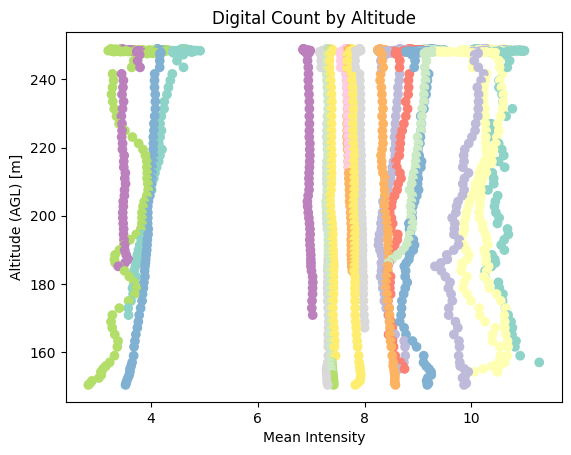

In [22]:
plt.scatter(roimean, altitude_abs[roiframe], c=roiinstance, cmap="Set3")
plt.title("Digital Count by Altitude")
plt.xlabel("Mean Intensity")
plt.ylabel("Altitude (AGL) [m]")
plt.show()

Plot **Standard Deviation**

In [ ]:
plt.scatter(roistdev, altitude_rel[roiframe], c=roiinstance, cmap="Set3")
plt.title("Variation by Altitude")
plt.xlabel("Standard Deviation")
plt.ylabel("Altitude (AGL) [m]")
plt.show()

Plot **ROI Instance**

In [ ]:
plt.figure()
for instance in np.unique(roiinstance):
    plt.plot(roimean[roiinstance==instance], altitude_rel[roiframe][roiinstance==instance])
plt.xlabel("Mean Intensity")
plt.ylabel("Altitude (AGL) [m]")
plt.title("Digital Count by Altitude")
plt.show()

Plot **Mean w/ Error Bars**

In [ ]:
plt.figure()
for instance in np.unique(roiinstance):
    plt.errorbar(roimean[roiinstance==instance], altitude_rel[roiframe][roiinstance==instance], xerr=roistdev[roiinstance==instance])
plt.xlabel("Mean Intensity")
plt.ylabel("Altitude (AGL) [m]")
plt.title("Digital Count by Altitude (with error bars)")
plt.show()

Plot **Mean w/ Violin Plot**

In [ ]:
plt.figure()
for instance in np.unique(roiinstance):
    x = roimean[roiinstance==instance]
    y = altitude_rel[roiframe][roiinstance==instance]
    err = roistdev[roiinstance==instance]
    plt.plot(x, y)
    plt.fill_betweenx(y, x-err, x+err, alpha=0.4)
plt.xlabel("Mean Intensity")
plt.ylabel("Altitude (AGL) [m]")
plt.title("Digital Count by Altitude (with error fill)")
plt.show()

### Curve Interpolation

Fit regression curve

In [ ]:
# regress to ground radiance
from scipy.interpolate import UnivariateSpline

plt.figure()

pink_regions = [16, 17, 18, 19, 20, 21]
ground_leaving_radiances = []
altitude_radiances = []

for instance in np.unique(roiinstance):

    # flip the x and y axis for interpolation purposes
    means = roimean[roiinstance==instance]
    altitudes = altitude_rel[roiframe][roiinstance==instance]

    # if means in nan, cut the vectors to only the non-nan values
    valid_idxs = ~np.isnan(means)
    means = means[valid_idxs]
    altitudes = altitudes[valid_idxs]
    # sort by altitudes increasing
    altitudes = altitudes[np.argsort(altitudes)]
    means = means[np.argsort(altitudes)]

    # k=1 linear, k=2 quadratic, k=3 cubic (default), k=4, k=5 (max)
    spline = UnivariateSpline(altitudes, means, k=2, s=0)  # s=0 = interpolating, higher s is smoothing
    ground_radiance = spline(0)

    x_fine = np.linspace(0, altitudes.max(), 500)
    

    # append ground leaving radiance and altitude radiance for pink regions for upwelling and transmission calculations
    if instance in pink_regions:
        plt.plot(spline(x_fine), x_fine)
        plt.scatter(ground_radiance, 0, zorder=5, marker='x')

        ground_leaving_radiances.append(ground_radiance)
        altitude_radiances.append(means[-1]) # last mean is highest altitude radiance value

Plot regression curve

In [ ]:
plt.ylabel("Altitude (AGL) [m]")
plt.xlabel("Mean Intensity")
plt.title("Digital Count by Altitude (interpolated)")
plt.show()

Calculate upwelling transmission values for region

In [ ]:
# Transmission values for pink regions
plt.figure()

for i in range(len(pink_regions)):
    plt.scatter(ground_leaving_radiances[i], altitude_radiances[i], label=f"Region {pink_regions[i]}")
    
plt.legend(pink_regions, loc="best")
plt.xlabel("Ground Leaving Radiance")
plt.ylabel("Radiance at Altitude")